---
title: IMPORTS
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: lista-4-projekt-grupowy-1
    language: python
    name: python3
---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [2]:
data_dir = Path("..") / "data"

df1 = pd.read_csv(data_dir / "neo.csv")
df2 = pd.read_csv(data_dir / "neo_v2.csv")

print(df1.shape)
print(df2.shape)
print(df1.equals(df2))

(90836, 10)
(90836, 10)
True


A zatem te dwa zbiory są identyczne. Będziemy pracować na zbiorze zawartym w pliku `neo_v2.csv`

Opis kolumn: ([Źródło](https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects/data?select=neo_v2.csv))
| Column Name | Description |
| :--- | :--- |
| `id` | Unique Identifier for each Asteroid |
| `name` | Name given by NASA |
| `est_diameter_min` | Minimum Estimated Diameter in Kilometres |
| `est_diameter_max` | Maximum Estimated Diameter in Kilometres |
| `relative_velocity` | Velocity Relative to Earth |
| `miss_distance` | Distance in Kilometres missed |
| `orbiting_body` | Planet that the asteroid orbits |
| `sentry_object` | Included in sentry - an automated collision monitoring system |
| `absolute_magnitude` | Describes intrinsic luminosity |
| `hazardous` | Boolean feature that shows whether asteroid is harmful or not |

In [3]:
df = pd.read_csv(data_dir / "neo_v2.csv")

# EDA

In [4]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [6]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


Nie ma żadnych nulli ani missing values, name najsensowniej usunac w pozniejszej fazie

In [7]:
df.duplicated(["id", "name"]).sum()

np.int64(63413)

Asteroida z tym samym id bądź name może wystąpić kilka razy.
Ma to sens jeśli popatrzymy na to co reprezentują te dane:
Każdy wiersz oznacza tutaj wydarzenie w którym asteroida zbliżyła się blisko do ziemi.
To wydarzenie jest oceniane jako groźne/niegroźne.
Jedna asteroida mogła zatem kilkukrotnie zbliżyć się do Ziemii, więc pojawia się kilka razy w zbiorze danych.
Ta wiedza będzie istotna podczas podziału na zbiór treningowy i testowy, ponieważ kluczowe jest, aby asteroida o danym id znalazła się tylko w jednym z tych zbiorów.
Inaczej model nauczy się innych jej danych (tych które są stałe między zbliżeniami) "na pamięć" = wyciek danych.

In [8]:
print(df["orbiting_body"].unique())

['Earth']


In [9]:
print(df["sentry_object"].unique())

[False]


Czyli te informacje beda bezuzyteczne dla modelu, poniewaz kazdy rekord ja ma w tej samej postaci ( value )

In [10]:
df = df.drop(["name", "orbiting_body", "sentry_object"], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   est_diameter_min    90836 non-null  float64
 2   est_diameter_max    90836 non-null  float64
 3   relative_velocity   90836 non-null  float64
 4   miss_distance       90836 non-null  float64
 5   absolute_magnitude  90836 non-null  float64
 6   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(5), int64(1)
memory usage: 4.2 MB


/tmp/nix-shell.DSD91u/ipykernel_81675/178740576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hazardous_counts.index, y=hazardous_counts.values, palette="viridis")


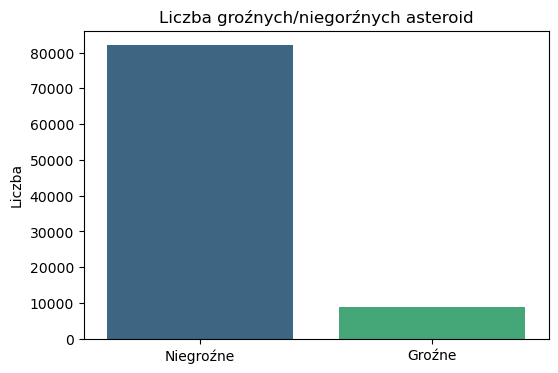

In [11]:
hazardous_counts = df["hazardous"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=hazardous_counts.index, y=hazardous_counts.values, palette="viridis")
plt.title("Liczba groźnych/niegorźnych asteroid")
plt.xlabel("")
plt.ylabel("Liczba")
plt.xticks([0, 1], ["Niegroźne", "Groźne"])
plt.show()

In [12]:
print(f"Groźne NEO: {hazardous_counts[True]}")
print(f"Niegroźne NEO: {hazardous_counts[False]}")
print(
    f"Procent groźnych NEO: {hazardous_counts[True] / (hazardous_counts[True] + hazardous_counts[False]) * 100:.2f}%"
)

Groźne NEO: 8840
Niegroźne NEO: 81996
Procent groźnych NEO: 9.73%


Jak widać, klasy są niezbalansowane, będzie trzeba skupić na tym uwage przy tworzeniu modelu i jego ewaluacji

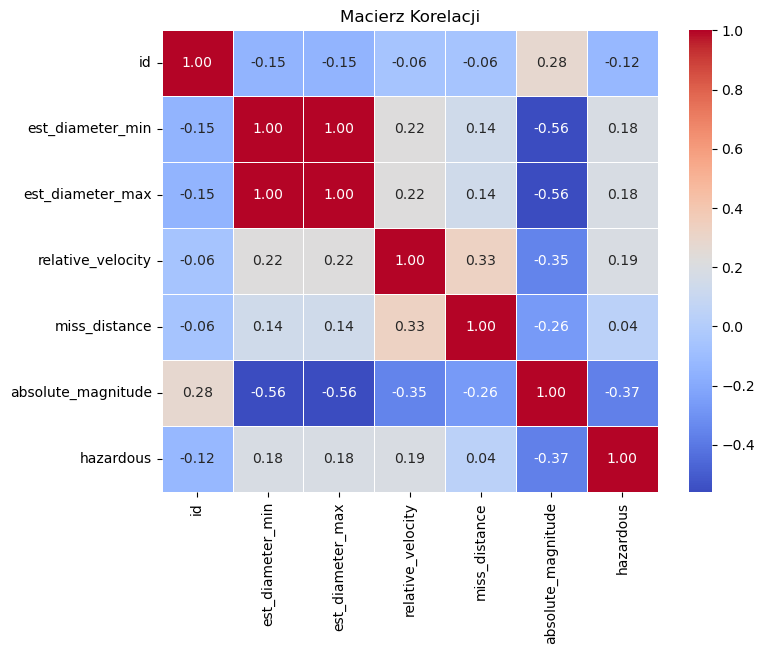

In [13]:
df_corr = df.copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Macierz Korelacji")
plt.show()

A zatem usuwamy również jedną z [est_diameter_min, est_diameter_max] z powodu ich idealnej korelacji liniowej

In [14]:
df = df.drop("est_diameter_max", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   est_diameter_min    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   absolute_magnitude  90836 non-null  float64
 5   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(4), int64(1)
memory usage: 3.6 MB


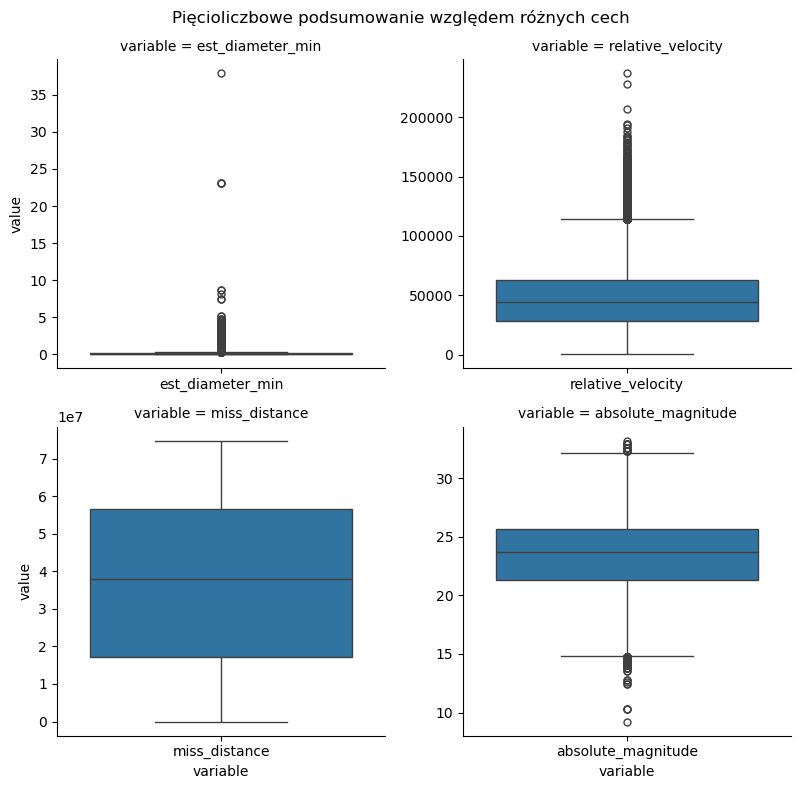

In [15]:
melted = pd.melt(df.drop("id", axis=1).select_dtypes(include=["number"]))
sns.catplot(
    data=melted,
    x="variable",
    y="value",
    kind="box",
    col="variable",
    col_wrap=2,
    sharey=False,
    sharex=False,
    height=4, 
    aspect=1
)

plt.suptitle("Pięcioliczbowe podsumowanie względem różnych cech")
plt.tight_layout()
plt.show()

Widzimy, że est_diameter_min ma bardzo dużo outlierów. Sprawdźmy, czy cechują się oni czymś szczególnym

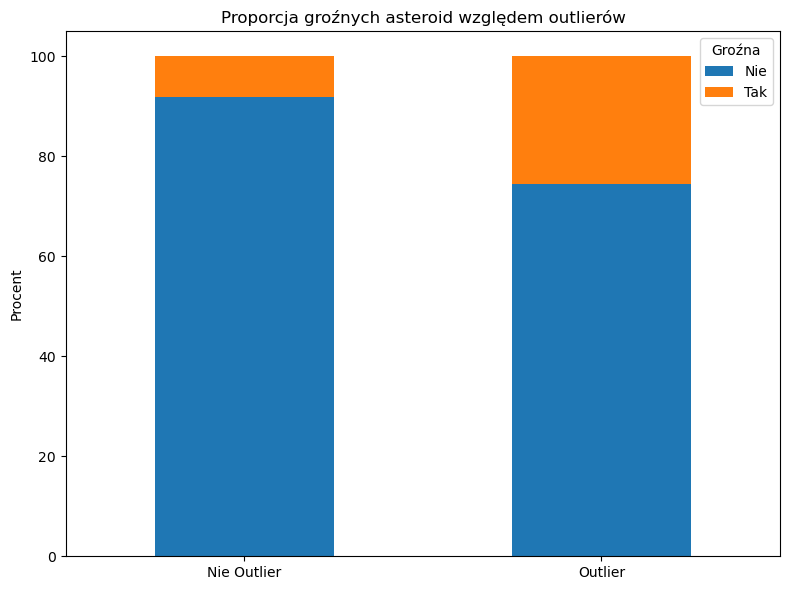

In [16]:
Q1 = df["est_diameter_min"].quantile(0.25)
Q3 = df["est_diameter_min"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (df["est_diameter_min"] < lower_bound) | (df["est_diameter_min"] > upper_bound)

df["outlier"] = np.where(is_outlier, 1, 0)

compacted_df = df[["hazardous", "outlier"]]

cross = pd.crosstab(compacted_df["outlier"], compacted_df["hazardous"], normalize="index") * 100

cross.index = ["Nie Outlier", "Outlier"]

ax = cross.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6),
    title="Proporcja groźnych asteroid względem outlierów",
    ylabel="Procent",
    xlabel="",
)

plt.legend(title="Groźna", labels=["Nie", "Tak"])

plt.xticks(rotation=0) 

plt.tight_layout() 
plt.show()
df = df.drop("outlier", axis=1)

Sprawdźmy jeszcze jak dokładnie wyglądają wiersze dla dwóch największych outlierów (na wykresie widać iż odbiegają oni znacznie od pozostałych)
Operację te wykonajmy na oryginalnym zbiorze danych, bez usuniętych kolumn, możliwe że te dwie asteroidy są specjalne i należy im się dokładniej przyjrzeć

In [17]:
max_diameters = df.groupby("id")["est_diameter_min"].max().nlargest(2).index
df_fresh = pd.read_csv(data_dir / "neo_v2.csv")
df_fresh[df_fresh["id"].isin(max_diameters)]

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
12709,2000433,433 Eros (A898 PA),23.043847,51.527608,15884.252623,5.468808e+07,Earth,False,10.31,False
36418,2001036,1036 Ganymed (A924 UB),37.892650,84.730541,51496.923293,5.372124e+07,Earth,False,9.23,False
37651,2000433,433 Eros (A898 PA),23.043847,51.527608,21402.705247,2.672952e+07,Earth,False,10.31,False
56533,2000433,433 Eros (A898 PA),23.043847,51.527608,21761.703426,3.120592e+07,Earth,False,10.31,False


W zależności od wybranego modelu, tych dwóch outlierów może spowodować wiele szkód.
W szczególności przez to, że pomimo największej średnicy, te asteroidy nie są uznawane za groźne (mają te same klasy przy każdym zbliżeniu).
Poprzedni wykres pokazał, że to czy asteroida jest outlierem pod względem średnicy ma niewielki wpływ na to czy jest ona groźna. 
Ponadto, przez to że mamy tylko 4 zbliżenia z tak odbiegającą średnicą w naszych danych, nie możemy polegać na tym, że model nauczy się przewidywać klas dla podobnych średnić - jest za mało danych.
Dlatego możemy usunąć wszystkie wiersze powiązane z tymi asteroidami, biorąc pod uwagę że operujemy na zbiorze zawierającym >90 tys. wierszy

In [18]:
df = df[~df["id"].isin(max_diameters)]